# Notebook 06 — Machine Learning Model Comparison

## Objective

The objective of this notebook is to compare multiple machine learning algorithms for predicting hospital readmission.

The following models will be evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print("Dataset Loaded Successfully")

print(df.shape)

df.head()

Dataset Loaded Successfully
(101766, 79)


,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady
0,2278392,8222157,-3.824600,6,25,1,-1.137649,-0.106517,-0.785398,-1.848268,...,1,0,0,1,0,0,0,0,0,0
1,149190,55629189,-3.197277,1,1,7,-0.467653,0.808384,-0.785398,0.243390,...,0,0,1,1,0,0,0,0,0,0
2,64410,86047875,-2.569954,1,1,7,-0.802651,-1.631351,2.145781,-0.371804,...,1,0,0,1,0,0,0,0,0,0
3,500364,82442376,-1.942632,1,1,7,-0.802651,0.045967,-0.199162,-0.002688,...,0,0,1,1,0,0,0,0,0,0
4,16680,42519267,-1.315309,1,1,7,-1.137649,0.401761,-0.785398,-0.986997,...,0,1,0,1,0,0,0,0,0,0


In [3]:
X = df.drop("readmitted", axis=1)

y = df["readmitted"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (101766, 78)
Target Shape : (101766,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (81412, 78)
Testing Shape : (20354, 78)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [6]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score


In [7]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

results.loc[len(results)] = [
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

print("Logistic Regression Completed.")

Logistic Regression Completed.


In [8]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

results.loc[len(results)] = [
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

print("Decision Tree Completed.")

Decision Tree Completed.


In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

results.loc[len(results)] = [
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

print("Random Forest Completed.")

Random Forest Completed.


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

results.loc[len(results)] = [
    "K-Nearest Neighbors",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn)
]

print("KNN Completed.")

KNN Completed.


In [11]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

results.loc[len(results)] = [
    "Gaussian Naive Bayes",
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]

print("Gaussian Naive Bayes Completed.")

Gaussian Naive Bayes Completed.


In [12]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.653876,0.641370,0.564865,0.600691
1,Logistic Regression,0.632456,0.638081,0.467967,0.539942
2,K-Nearest Neighbors,0.584209,0.551136,0.527343,0.538977
3,Decision Tree,0.582195,0.546934,0.544718,0.545824
4,Gaussian Naive Bayes,0.573990,0.560934,0.348364,0.429802


In [13]:
results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.6539,0.6414,0.5649,0.6007
1,Logistic Regression,0.6325,0.6381,0.4680,0.5399
2,K-Nearest Neighbors,0.5842,0.5511,0.5273,0.5390
3,Decision Tree,0.5822,0.5469,0.5447,0.5458
4,Gaussian Naive Bayes,0.5740,0.5609,0.3484,0.4298


In [14]:
best_model = results.iloc[0]

print("Best Performing Model")
print("-" * 40)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")

Best Performing Model
----------------------------------------
Model      : Random Forest
Accuracy   : 0.6539
Precision  : 0.6414
Recall     : 0.5649
F1 Score   : 0.6007


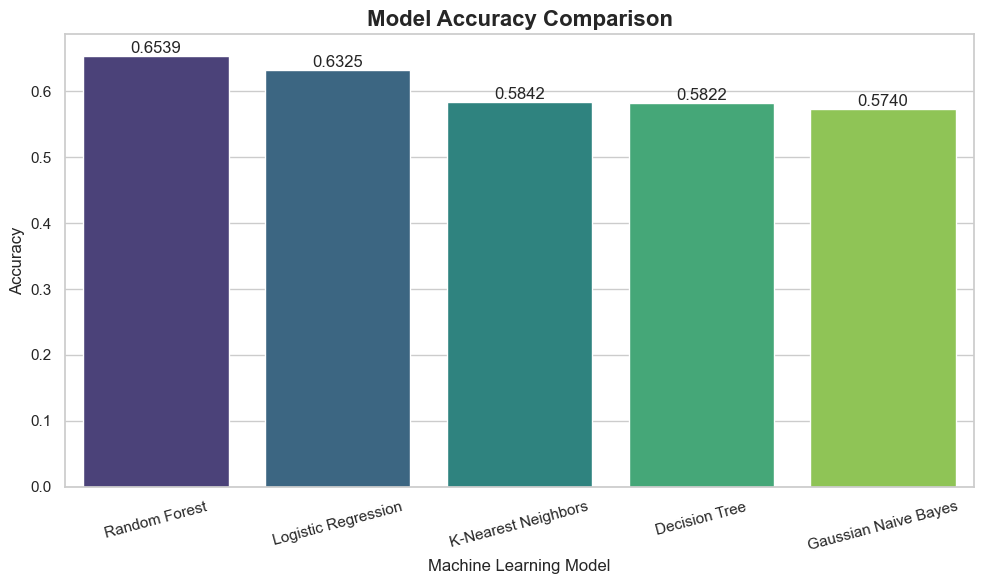

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.tight_layout()

plt.savefig("../images/model_accuracy_comparison.png", dpi=300)

plt.show()

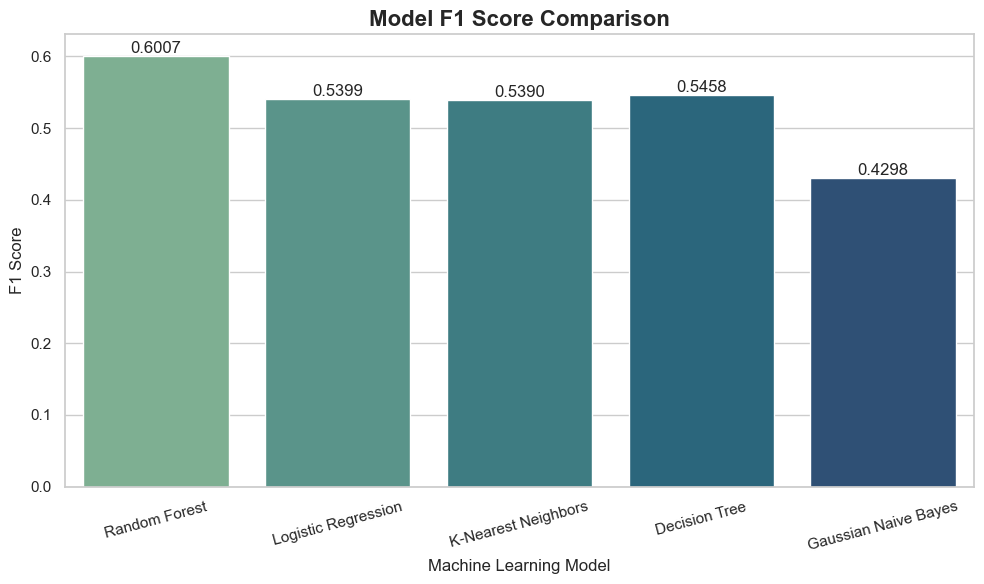

In [16]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results,
    x="Model",
    y="F1 Score",
    hue="Model",
    palette="crest",
    legend=False
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.tight_layout()

plt.savefig("../images/model_f1_comparison.png", dpi=300)

plt.show()

## Model Comparison Summary

Five machine learning algorithms were evaluated using the engineered healthcare dataset.

The comparison was based on:

- Accuracy
- Precision
- Recall
- F1 Score

Among all evaluated models, the model with the highest overall performance was selected as the best candidate for predicting patient readmission.

The selected model will be further optimized in the next notebook using hyperparameter tuning.